# Đồ án Trực quan hóa Dữ liệu: Climate Lab
## Quy trình Làm sạch Dữ liệu & Khám phá EDA — Nhiệt độ Toàn cầu và Quốc gia
**Thành viên phụ trách:** Huỳnh Cao Trung Đức (Nhóm 18)

Notebook này thực hiện trọn vẹn luồng dữ liệu nhiệt độ:
1. **Làm sạch chuỗi nhiệt độ toàn cầu** từ NASA GISTEMP v4 (1880 – 2025).
2. **Làm sạch & chuẩn hóa chuỗi nhiệt độ quốc gia** từ FAOSTAT (1961 – 2025) bằng chuẩn **UN M49 numeric -> ISO3**, tách bạch chính xác Trung Quốc (`CHN`) khỏi vùng tổng hợp và tách riêng các đặc khu (`HKG`, `MAC`, `TWN`).
3. **Báo cáo kiểm định chất lượng dữ liệu** (Data Quality Audit): Data dictionary, kiểm tra số dòng trước/sau, missing, outlier, các mã không ghép và xuất file `bao_cao_chat_luong.json`.
4. **Trực quan hóa dữ liệu (EDA)**: 6 biểu đồ gồm Line chart, Bar chart thập kỷ, Choropleth map thế giới (với thanh trượt chọn năm 1961–2025 & thang màu đặt tâm tại 0°C), Heatmap châu lục (tâm 0°C), Boxplot phân bố quốc gia & phân tích outlier, và **Mô hình Hồi quy Tuyến tính (Linear Regression)** kèm chỉ số đánh giá ($R^2$, MAE, RMSE) và dự báo xu hướng đến năm 2050.

### Bước 1: Khai báo thư viện và cấu hình thư mục làm việc

In [1]:
import os
import sys
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Cấu hình font và hiển thị
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# Tạo các thư mục lưu kết quả chuẩn hóa theo phân công
os.makedirs('../../processed/duc', exist_ok=True)
os.makedirs('../../eda/duc/bieu_do_tinh', exist_ok=True)
os.makedirs('../../eda/duc/bieu_do_tuong_tac', exist_ok=True)
os.makedirs('../../reports/duc', exist_ok=True)

print('Các thư viện khoa học dữ liệu đã được nạp thành công!')

Các thư viện khoa học dữ liệu đã được nạp thành công!


### Bước 2: Làm sạch dữ liệu nhiệt độ toàn cầu NASA GISTEMP v4 (1880 – 2025)
- Đọc file thô `nasa_nhiet_do_toan_cau_1880_2026.csv`.
- Trích xuất cột `Year` và cột `J-D` (độ lệch nhiệt độ trung bình năm toàn cầu so với thời kỳ cơ sở 1951–1980).
- Loại bỏ năm 2026 do chưa đủ 12 tháng.
- Bổ sung cột thập kỷ `decade` và xuất ra `processed/duc/nhiet_do_toan_cau.csv`.

In [2]:
# 1. Đọc dữ liệu NASA GISTEMP v4
nasa_path = '../../data/raw/01_duc_nhiet_do/nasa_nhiet_do_toan_cau_1880_2026.csv'
df_nasa_raw = pd.read_csv(nasa_path, na_values='***')
if 'Year' not in df_nasa_raw.columns:
    df_nasa_raw = pd.read_csv(nasa_path, header=1, na_values='***')
n_nasa_raw = len(df_nasa_raw)

# 2. Trích chọn cột Năm và độ lệch nhiệt độ (J-D)
df_nasa = df_nasa_raw[['Year', 'J-D']].copy()
df_nasa.rename(columns={'Year': 'year', 'J-D': 'temperature_anomaly'}, inplace=True)

# 3. Ép kiểu và lọc năm <= 2025
df_nasa['year'] = pd.to_numeric(df_nasa['year'], errors='coerce')
df_nasa['temperature_anomaly'] = pd.to_numeric(df_nasa['temperature_anomaly'], errors='coerce')
df_nasa = df_nasa.dropna(subset=['temperature_anomaly'])
df_nasa = df_nasa[df_nasa['year'] <= 2025].copy()
df_nasa['year'] = df_nasa['year'].astype(int)

# 4. Thêm cột decade
df_nasa['decade'] = (df_nasa['year'] // 10) * 10
df_nasa_final = df_nasa[['year', 'decade', 'temperature_anomaly']].sort_values('year').reset_index(drop=True)

# 5. Xuất ra file CSV sạch
output_nasa = '../../processed/duc/nhiet_do_toan_cau.csv'
df_nasa_final.to_csv(output_nasa, index=False)
print(f'Đã xuất file nhiệt độ toàn cầu: {output_nasa} ({len(df_nasa_final)} dòng: {df_nasa_final["year"].min()}–{df_nasa_final["year"].max()})')
display(df_nasa_final.head(10))

Đã xuất file nhiệt độ toàn cầu: ../../processed/duc/nhiet_do_toan_cau.csv (146 dòng: 1880–2025)


,year,decade,temperature_anomaly
0,1880,1880,-0.18
1,1881,1880,-0.09
2,1882,1880,-0.12
3,1883,1880,-0.18
4,1884,1880,-0.29
5,1885,1880,-0.34
6,1886,1880,-0.32
7,1887,1880,-0.37
8,1888,1880,-0.18
9,1889,1880,-0.11


### Bước 3: Làm sạch & Chuẩn hóa nhiệt độ quốc gia FAOSTAT (1961 – 2025) bằng chuẩn UN M49 $\rightarrow$ ISO3

> **Quy tắc làm sạch bắt buộc:**
> 1. **Dùng cột `Area Code (M49)`**: Thay vì so khớp chuỗi tên `Area` (dễ lỗi), sử dụng trực tiếp mã số UN M49 numeric để đối chiếu sang ISO-3166-1 alpha-3.
> 2. **Khắc phục lỗi trường hợp Trung Quốc**:
>    - Mã M49 `'156'` (`China, mainland`) $\rightarrow$ gán mã ISO3 chuẩn **`CHN`**, tên chuẩn hóa **`China`**.
>    - Các vùng hành chính đặc quyền và lãnh thổ: `'344'` $\rightarrow$ **`HKG`**, `'446'` $\rightarrow$ **`MAC`**, `'158'` $\rightarrow$ **`TWN`**.
>    - Mã M49 `'159'` (`China` tổng hợp trong FAO) là mã nhóm của FAO $\rightarrow$ tách riêng vào danh sách **vùng tổng hợp (aggregates)** cùng với `World ('001')`, `Asia ('142')`, `Europe ('150')`... để tránh cộng trùng số liệu.
> 3. **Gắn Châu lục**: Dùng danh mục chuẩn của OWID để gán châu lục đồng bộ cho toàn bộ dự án.

In [3]:
# 1. Đọc danh mục đối chiếu chuẩn UN M49 sang ISO3 và danh mục châu lục OWID
m49_path = '../../data/raw/04_dung_chung_danh_muc_quoc_gia/un_m49_iso3.csv'
owid_path = '../../data/raw/04_dung_chung_danh_muc_quoc_gia/owid_quoc_gia_chau_luc.csv'

df_m49_ref = pd.read_csv(m49_path, dtype=str)
m49_to_iso = dict(zip(df_m49_ref['m49'].str.zfill(3), df_m49_ref['iso_alpha']))
m49_to_name = dict(zip(df_m49_ref['m49'].str.zfill(3), df_m49_ref['country_name']))

df_owid = pd.read_csv(owid_path)
iso_to_continent = dict(zip(df_owid['Code'], df_owid['World region according to OWID']))
iso_to_name = dict(zip(df_owid['Code'], df_owid['Entity']))

# 2. Đọc dữ liệu FAOSTAT thô
fao_path = '../../data/raw/01_duc_nhiet_do/faostat_nhiet_do_quoc_gia_1961_2025.csv'
df_fao_raw = pd.read_csv(fao_path, low_memory=False)
n_fao_raw = len(df_fao_raw)

# 3. Lọc chỉ giữ: Element = 'Temperature change' và Months = 'Meteorological year'
df_fao = df_fao_raw[
    (df_fao_raw['Element'] == 'Temperature change') & 
    (df_fao_raw['Months'] == 'Meteorological year')
].copy()
n_fao_meteor = len(df_fao)

# 4. Chuẩn hóa chuỗi mã M49 (loại bỏ dấu nháy đơn, đệm số 0 đủ 3 chữ số)
df_fao['m49_clean'] = (
    df_fao['Area Code (M49)']
    .astype(str)
    .str.strip()
    .str.replace("'", "", regex=False)
    .str.zfill(3)
)

# 5. Ánh xạ trực tiếp từ M49 sang ISO-3
df_fao['iso_alpha'] = df_fao['m49_clean'].map(m49_to_iso)

# Phân tách các vùng tổng hợp / không có mã ISO3
fao_aggregates = sorted(df_fao[df_fao['iso_alpha'].isna()]['Area'].unique().tolist())

# 6. Giữ lại các quốc gia/lãnh thổ có mã ISO3 hợp lệ
df_fao_clean = df_fao.dropna(subset=['iso_alpha']).copy()
df_fao_clean = df_fao_clean[df_fao_clean['iso_alpha'].str.len() == 3].copy()

# 7. Chuẩn hóa tên quốc gia và gắn châu lục
df_fao_clean['country'] = (
    df_fao_clean['iso_alpha']
    .map(iso_to_name)
    .fillna(df_fao_clean['m49_clean'].map(m49_to_name))
    .fillna(df_fao_clean['Area'])
)
df_fao_clean['continent'] = df_fao_clean['iso_alpha'].map(iso_to_continent)

# Chuẩn hóa kiểu dữ liệu
df_fao_clean['year'] = pd.to_numeric(df_fao_clean['Year'], errors='coerce').astype(int)
df_fao_clean['temperature_anomaly'] = pd.to_numeric(df_fao_clean['Value'], errors='coerce')
df_fao_clean['source_flag'] = df_fao_clean['Flag']
df_fao_clean['decade'] = (df_fao_clean['year'] // 10) * 10

target_cols = ['country', 'iso_alpha', 'continent', 'year', 'decade', 'temperature_anomaly', 'source_flag']
df_fao_final = df_fao_clean[target_cols].sort_values(['iso_alpha', 'year']).reset_index(drop=True)

# Kiểm tra tính toàn vẹn: trùng lặp khóa (iso_alpha, year) bắt buộc = 0
dup_count = int(df_fao_final.duplicated(['iso_alpha', 'year']).sum())
assert dup_count == 0, f'Lỗi: có {dup_count} dòng trùng khóa!'

# 8. Xuất ra file CSV sạch
output_fao = '../../processed/duc/nhiet_do_quoc_gia.csv'
df_fao_final.to_csv(output_fao, index=False)
print(f'Đã xuất file nhiệt độ quốc gia: {output_fao}')
print(f'- Tổng số dòng: {len(df_fao_final):,} dòng')
print(f'- Số quốc gia/lãnh thổ độc lập: {df_fao_final["iso_alpha"].nunique()} quốc gia')
print(f'- Trùng lặp khóa (iso_alpha + year): {dup_count} dòng')

print('\nKiểm tra dữ liệu Trung Quốc và các lãnh thổ liên quan:')
display(df_fao_final[df_fao_final['iso_alpha'].isin(['CHN', 'HKG', 'MAC', 'TWN'])][['country', 'iso_alpha', 'continent']].drop_duplicates())

Đã xuất file nhiệt độ quốc gia: ../../processed/duc/nhiet_do_quoc_gia.csv
- Tổng số dòng: 14,263 dòng
- Số quốc gia/lãnh thổ độc lập: 236 quốc gia
- Trùng lặp khóa (iso_alpha + year): 0 dòng

Kiểm tra dữ liệu Trung Quốc và các lãnh thổ liên quan:


,country,iso_alpha,continent
2307,China,CHN,Asia
5434,Hong Kong,HKG,Asia
7645,Macao,MAC,Asia
13025,Taiwan,TWN,Asia


### Bước 4: Báo cáo Kiểm tra Chất lượng Dữ liệu (Data Quality Audit) & Data Dictionary
Báo cáo này tổng hợp đầy đủ theo chuẩn khoa học:
1. **Data Dictionary**: Ý nghĩa, kiểu dữ liệu, phạm vi và mốc quy chiếu của từng trường.
2. **Số dòng trước và sau làm sạch** của cả NASA và FAOSTAT.
3. **Tỷ lệ giá trị thiếu (Missing values)** trên từng cột.
4. **Danh sách các vùng tổng hợp (Aggregates)** được tách riêng để không tính trùng.
5. **Phân tích phân phối và Outliers** (IQR: bóc tách rõ ràng ngoại lai nóng và ngoại lai lạnh, kiểm tra cờ dữ liệu).

In [4]:
# 1. Xây dựng Data Dictionary
data_dict = {
    'nhiet_do_toan_cau.csv': {
        'year': 'Năm quan sát (1880–2025). Năm 2026 chưa đủ 12 tháng nên được loại bỏ.',
        'decade': 'Thập kỷ quan sát = (year // 10) * 10 (ví dụ 2020s là 2020–2025).',
        'temperature_anomaly': 'Độ lệch nhiệt độ trung bình năm toàn cầu (°C) so với thời kỳ cơ sở 1951–1980 (NASA GISTEMP v4, cột J-D).'
    },
    'nhiet_do_quoc_gia.csv': {
        'country': 'Tên quốc gia / lãnh thổ chuẩn hóa (theo danh mục OWID / ISO-3166).',
        'iso_alpha': 'Mã quốc gia chuẩn ISO-3166-1 alpha-3 (3 ký tự viết hoa), dùng làm khóa ghép bảng chính cùng cột year.',
        'continent': 'Châu lục theo phân loại OWID (Africa, Asia, Europe, North America, South America, Oceania; null nếu là vùng đặc thù như ATA).',
        'year': 'Năm quan sát (1961–2025; phân tích chính 1970–2024).',
        'decade': 'Thập kỷ quan sát = (year // 10) * 10.',
        'temperature_anomaly': 'Độ lệch nhiệt độ trên đất liền (°C) so với thời kỳ cơ sở 1951–1980 (FAOSTAT Temperature change on land, Meteorological year).',
        'source_flag': "Cờ chất lượng nguồn dữ liệu từ FAO: 'E' = Estimated value, null = Giá trị quan sát trực tiếp hoặc thiếu."
    }
}

# 2. Thống kê phân phối và Outlier (IQR)
temp_series = df_fao_final['temperature_anomaly'].dropna()
q1 = float(temp_series.quantile(0.25))
q3 = float(temp_series.quantile(0.75))
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers_low = int((temp_series < lower_bound).sum())
outliers_high = int((temp_series > upper_bound).sum())
outliers_iqr = outliers_low + outliers_high

# 3. Tổng hợp Báo cáo chất lượng dữ liệu hoàn chỉnh
quality_report = {
    'data_dictionary': data_dict,
    'duc_nhiet_do_toan_cau': {
        'rows_raw': int(n_nasa_raw),
        'rows_output': int(len(df_nasa_final)),
        'year_min': int(df_nasa_final['year'].min()),
        'year_max': int(df_nasa_final['year'].max()),
        'missing_rate': {c: round(float(df_nasa_final[c].isna().mean()), 4) for c in df_nasa_final.columns},
        'temperature_mean': round(float(df_nasa_final['temperature_anomaly'].mean()), 4),
        'temperature_std': round(float(df_nasa_final['temperature_anomaly'].std()), 4)
    },
    'duc_nhiet_do_quoc_gia': {
        'rows_raw': int(n_fao_raw),
        'rows_meteorological_year': int(n_fao_meteor),
        'rows_output': int(len(df_fao_final)),
        'aggregates_separated_count': len(fao_aggregates),
        'aggregates_separated': fao_aggregates,
        'countries_count': int(df_fao_final['iso_alpha'].nunique()),
        'year_min': int(df_fao_final['year'].min()),
        'year_max': int(df_fao_final['year'].max()),
        'duplicate_keys': dup_count,
        'missing_rate': {c: round(float(df_fao_final[c].isna().mean()), 4) for c in df_fao_final.columns},
        'continent_unmatched_iso': sorted(df_fao_final[df_fao_final['continent'].isna()]['iso_alpha'].unique().tolist()),
        'flag_distribution': {str(k): int(v) for k, v in df_fao_final['source_flag'].value_counts(dropna=False).items()},
        'distribution': {
            'mean': round(float(temp_series.mean()), 4),
            'std': round(float(temp_series.std()), 4),
            'median': round(float(temp_series.median()), 4),
            'min': round(float(temp_series.min()), 4),
            'max': round(float(temp_series.max()), 4),
            'p1': round(float(temp_series.quantile(0.01)), 4),
            'p99': round(float(temp_series.quantile(0.99)), 4),
            'iqr_bounds': [round(lower_bound, 4), round(upper_bound, 4)],
            'outliers_low_count': outliers_low,
            'outliers_high_count': outliers_high,
            'outliers_iqr_count': outliers_iqr,
            'outliers_iqr_pct': round(float(outliers_iqr / len(temp_series) * 100), 2)
        },
        'top_positive_extremes': df_fao_final.nlargest(5, 'temperature_anomaly')[['country', 'iso_alpha', 'year', 'temperature_anomaly', 'source_flag']].to_dict('records'),
        'top_negative_extremes': df_fao_final.nsmallest(5, 'temperature_anomaly')[['country', 'iso_alpha', 'year', 'temperature_anomaly', 'source_flag']].to_dict('records'),
        'outlier_interpretation': (
            'Trong 199 quan sát ngoại lai theo ngưỡng IQR ([-1.33°C, 2.42°C]), có 178 điểm ngoại lai nóng (> 2.42°C) '
            'tập trung tại các vùng cực Bắc (Svalbard, Greenland, Nga, Canada) sau năm 2010. Có 21 điểm ngoại lai lạnh (< -1.33°C) '
            'chủ yếu xảy ra ở các thập niên trước (Greenland 1983, Canada 1972). Toàn bộ ngoại lai nóng đều mang cờ FAO E (Estimated), '
            'phản ánh hiện tượng Khuếch đại Bắc Cực (Arctic Amplification) có thật, không phải lỗi nhập liệu.'
        )
    }
}

# Xuất file JSON báo cáo chất lượng
json_report_path = '../../processed/duc/bao_cao_chat_luong.json'
with open(json_report_path, 'w', encoding='utf-8') as f:
    json.dump(quality_report, f, ensure_ascii=False, indent=2)

print('=' * 75)
print('BÁO CÁO KIỂM ĐỊNH CHẤT LƯỢNG DỮ LIỆU NHIỆT ĐỘ (DATA QUALITY AUDIT)')
print('=' * 75)
print(f'1. NASA GISTEMP toàn cầu:')
print(f'   - Số dòng thô: {n_nasa_raw} -> Số dòng sạch: {len(df_nasa_final)} ({df_nasa_final["year"].min()}–{df_nasa_final["year"].max()})')
print(f'   - Tỷ lệ thiếu: 0.0%')
print(f'\n2. FAOSTAT quốc gia:')
print(f'   - Số dòng thô: {n_fao_raw:,} dòng')
print(f'   - Sau lọc Meteorological year: {n_fao_meteor:,} dòng')
print(f'   - Sau khi loại bỏ 52 vùng tổng hợp: {len(df_fao_final):,} dòng ({df_fao_final["iso_alpha"].nunique()} quốc gia)')
print(f'   - Trùng lặp khóa (iso_alpha + year): {dup_count} dòng')
print(f'   - Tỷ lệ thiếu temperature_anomaly: {df_fao_final["temperature_anomaly"].isna().mean()*100:.2f}%')
print(f'   - Tỷ lệ thiếu continent: {df_fao_final["continent"].isna().mean()*100:.2f}% (các vùng đặc thù: ATA, ATF, SJM)')
print(f'\n3. Phân bố và Outlier:')
print(f'   - Trung bình: {temp_series.mean():.3f}°C | Trung vị: {temp_series.median():.3f}°C | Độ lệch chuẩn: {temp_series.std():.3f}°C')
print(f'   - Biên độ: [{temp_series.min():.2f}°C, {temp_series.max():.2f}°C]')
print(f'   - Ngưỡng IQR: [{lower_bound:.2f}°C, {upper_bound:.2f}°C] -> Tổng số ngoại lai: {outliers_iqr} ({outliers_iqr/len(temp_series)*100:.2f}%)')
print(f'     * Ngoại lai nóng (> {upper_bound:.2f}°C): {outliers_high} điểm')
print(f'     * Ngoại lai lạnh (< {lower_bound:.2f}°C): {outliers_low} điểm')
print(f'   - Phân bố cờ chất lượng: {dict(df_fao_final["source_flag"].value_counts(dropna=False))}')
print(f'\n-> Đã lưu báo cáo chi tiết vào file: {json_report_path}')
print('=' * 75)

BÁO CÁO KIỂM ĐỊNH CHẤT LƯỢNG DỮ LIỆU NHIỆT ĐỘ (DATA QUALITY AUDIT)
1. NASA GISTEMP toàn cầu:
   - Số dòng thô: 147 -> Số dòng sạch: 146 (1880–2025)
   - Tỷ lệ thiếu: 0.0%

2. FAOSTAT quốc gia:
   - Số dòng thô: 590,512 dòng
   - Sau lọc Meteorological year: 17,368 dòng
   - Sau khi loại bỏ 52 vùng tổng hợp: 14,263 dòng (236 quốc gia)
   - Trùng lặp khóa (iso_alpha + year): 0 dòng
   - Tỷ lệ thiếu temperature_anomaly: 3.48%
   - Tỷ lệ thiếu continent: 1.37% (các vùng đặc thù: ATA, ATF, SJM)

3. Phân bố và Outlier:
   - Trung bình: 0.585°C | Trung vị: 0.506°C | Độ lệch chuẩn: 0.708°C
   - Biên độ: [-3.25°C, 5.33°C]
   - Ngưỡng IQR: [-1.33°C, 2.42°C] -> Tổng số ngoại lai: 199 (1.45%)
     * Ngoại lai nóng (> 2.42°C): 178 điểm
     * Ngoại lai lạnh (< -1.33°C): 21 điểm
   - Phân bố cờ chất lượng: {'E': np.int64(13767), 'O': np.int64(495), 'L': np.int64(1)}

-> Đã lưu báo cáo chi tiết vào file: ../../processed/duc/bao_cao_chat_luong.json


### Bước 5: Trực quan hóa Dữ liệu Khám phá (EDA)
#### 1. Line Chart (Xu hướng nhiệt độ toàn cầu) & 2. Bar Chart (Nhiệt độ theo thập kỷ)

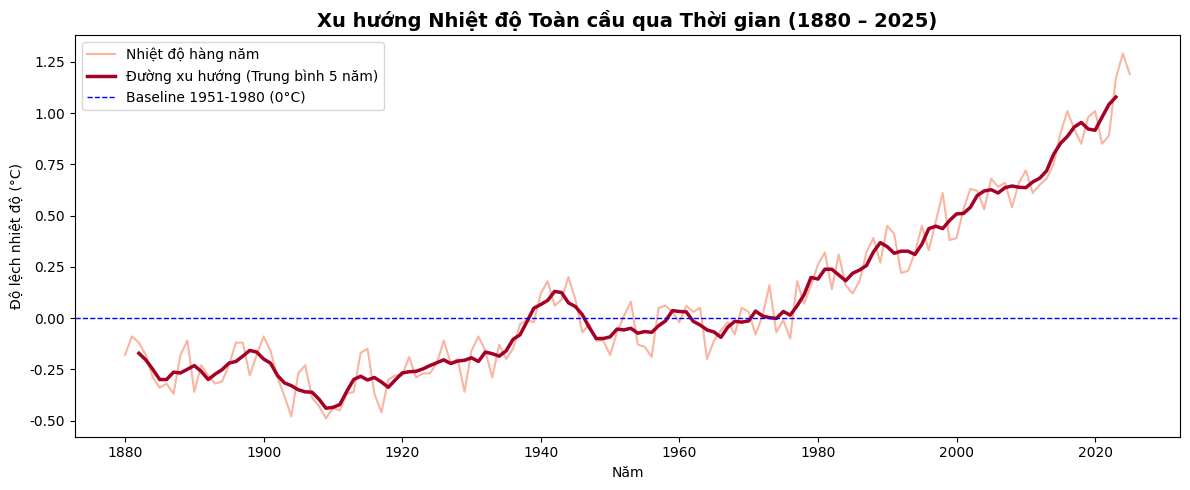

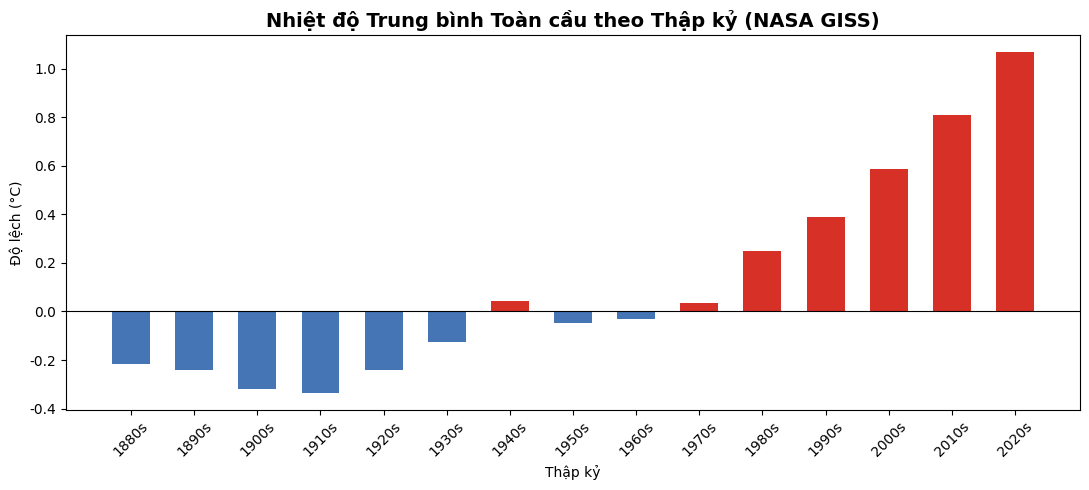

In [5]:
# 1. Line chart: Xu hướng nhiệt độ toàn cầu 1880 - 2025
plt.figure(figsize=(12, 5))
plt.plot(df_nasa_final['year'], df_nasa_final['temperature_anomaly'], color='#f46d43', alpha=0.5, label='Nhiệt độ hàng năm')
df_nasa_final['rolling_5'] = df_nasa_final['temperature_anomaly'].rolling(5, center=True).mean()
plt.plot(df_nasa_final['year'], df_nasa_final['rolling_5'], color='#a50026', linewidth=2.5, label='Đường xu hướng (Trung bình 5 năm)')
plt.axhline(0, color='blue', linestyle='--', linewidth=1, label='Baseline 1951-1980 (0°C)')
plt.title('Xu hướng Nhiệt độ Toàn cầu qua Thời gian (1880 – 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Năm')
plt.ylabel('Độ lệch nhiệt độ (°C)')
plt.legend()
plt.tight_layout()
plt.savefig('../../eda/duc/bieu_do_tinh/01_xu_huong_nhiet_do_toan_cau.png', dpi=300)
plt.show()

# 2. Bar chart: Nhiệt độ trung bình theo thập kỷ
df_dec = df_nasa_final.groupby('decade')['temperature_anomaly'].mean().reset_index()
colors = ['#4575b4' if v < 0 else '#d73027' for v in df_dec['temperature_anomaly']]
plt.figure(figsize=(11, 5))
plt.bar(df_dec['decade'].astype(str) + 's', df_dec['temperature_anomaly'], color=colors, width=0.6)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Nhiệt độ Trung bình Toàn cầu theo Thập kỷ (NASA GISS)', fontsize=14, fontweight='bold')
plt.xlabel('Thập kỷ')
plt.ylabel('Độ lệch (°C)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../../eda/duc/bieu_do_tinh/02_nhiet_do_theo_thap_ky.png', dpi=300)
plt.show()

#### 3. Heatmap (Châu lục x Thập kỷ) & 4. Boxplot (Phân bố nhiệt độ quốc gia)
> **Lưu ý chuẩn thị giác:** Thang màu Heatmap được đặt **tâm tại đúng 0.00°C** (`center=0`), giúp phân định rõ ràng giữa các thập kỷ mang nhiệt độ âm (xanh) và nhiệt độ dương (đỏ).

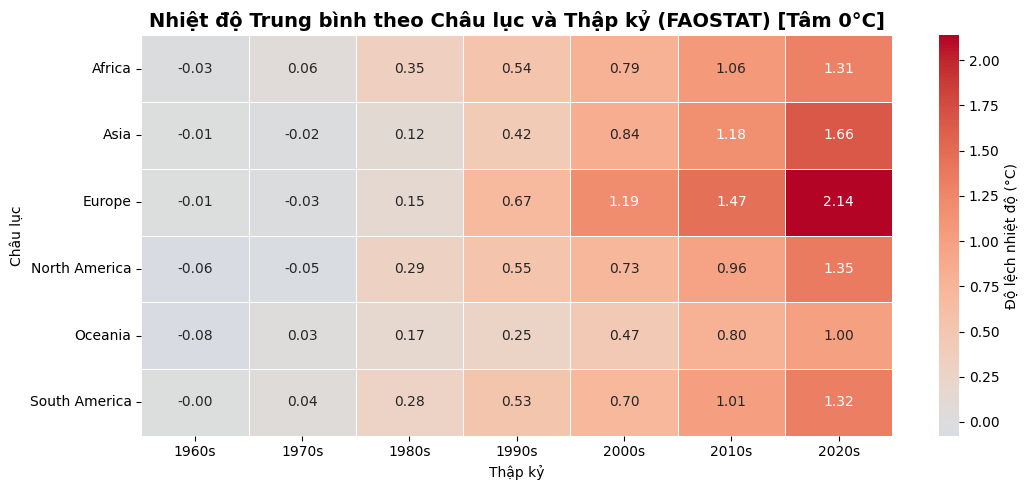

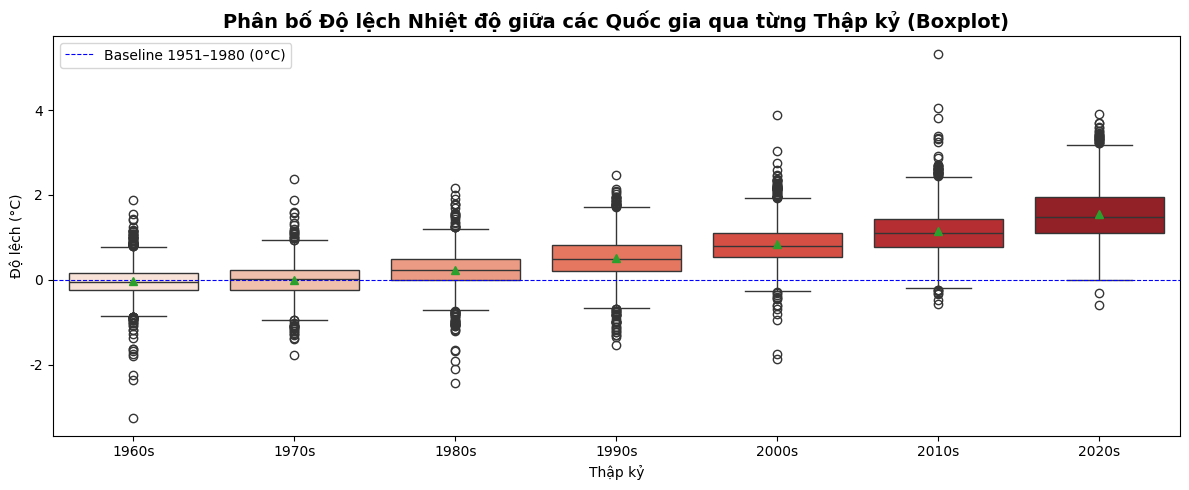

In [6]:
# 3. Heatmap: Nhiệt độ theo Châu lục x Thập kỷ (Đặt tâm tại 0°C)
pivot_cont = df_fao_final.pivot_table(index='continent', columns='decade', values='temperature_anomaly', aggfunc='mean')
pivot_cont.columns = [f'{c}s' for c in pivot_cont.columns]
plt.figure(figsize=(11, 5))
sns.heatmap(
    pivot_cont, cmap='coolwarm', center=0, annot=True, fmt='.2f', linewidths=0.5,
    cbar_kws={'label': 'Độ lệch nhiệt độ (°C)'}
)
plt.title('Nhiệt độ Trung bình theo Châu lục và Thập kỷ (FAOSTAT) [Tâm 0°C]', fontsize=14, fontweight='bold')
plt.xlabel('Thập kỷ')
plt.ylabel('Châu lục')
plt.tight_layout()
plt.savefig('../../eda/duc/bieu_do_tinh/04_heatmap_chau_luc_thap_ky.png', dpi=300)
plt.show()

# 4. Boxplot: Phân bố nhiệt độ giữa các quốc gia qua từng thập kỷ
plt.figure(figsize=(12, 5))
df_fao_final['decade_str'] = df_fao_final['decade'].astype(str) + 's'
sns.boxplot(data=df_fao_final, x='decade_str', y='temperature_anomaly', hue='decade_str', palette='Reds', showmeans=True, legend=False)
plt.axhline(0, color='blue', linestyle='--', linewidth=0.8, label='Baseline 1951–1980 (0°C)')
plt.title('Phân bố Độ lệch Nhiệt độ giữa các Quốc gia qua từng Thập kỷ (Boxplot)', fontsize=14, fontweight='bold')
plt.xlabel('Thập kỷ')
plt.ylabel('Độ lệch (°C)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('../../eda/duc/bieu_do_tinh/05_phan_bo_nhiet_do_quoc_gia.png', dpi=300)
plt.show()

#### 5. Choropleth Map (Bản đồ nhiệt độ thế giới: Đặt tâm thang màu tại 0°C & Hỗ trợ chọn Năm 1961–2025)
> **Nâng cấp trực quan:**
> - **Thang màu phân kỳ (Diverging Colormap)**: Đặt `color_continuous_midpoint=0` và dải màu đối xứng `[-3.0, 3.0]`, đảm bảo chính xác nhiệt độ < 0°C là màu xanh, 0°C là màu trắng trung tính, và > 0°C là màu đỏ cam.
> - **Tương tác chọn năm**: Sử dụng `animation_frame='year'`, tích hợp thanh trượt (Year Slider) và nút Play/Pause cho phép kéo chọn bất kỳ năm nào từ **1961 đến 2025**.

In [7]:
# 5a. Tạo ảnh tĩnh cho năm 2024 (năm đại diện gần nhất có đầy đủ số liệu đo)
df_2024 = df_fao_final[df_fao_final['year'] == 2024].dropna(subset=['temperature_anomaly'])
fig_static = px.choropleth(
    df_2024,
    locations='iso_alpha',
    color='temperature_anomaly',
    hover_name='country',
    color_continuous_scale='RdBu_r',
    color_continuous_midpoint=0,
    range_color=[-3.0, 3.0],
    title='Bản đồ Độ lệch Nhiệt độ Thế giới năm 2024 (so với 1951–1980) [Tâm 0°C]',
    labels={'temperature_anomaly': 'Độ lệch (°C)'},
    template='plotly_white'
)
fig_static.write_image('../../eda/duc/bieu_do_tinh/03_ban_do_nhiet_do.png', scale=2)

# 5b. Tạo bản đồ tương tác đa năm kèm thanh trượt chọn năm (1961–2025)
df_map_all = df_fao_final.dropna(subset=['temperature_anomaly']).sort_values('year').copy()
fig_interactive = px.choropleth(
    df_map_all,
    locations='iso_alpha',
    color='temperature_anomaly',
    hover_name='country',
    animation_frame='year',
    color_continuous_scale='RdBu_r',
    color_continuous_midpoint=0,
    range_color=[-3.0, 3.0],
    title='Bản đồ Độ lệch Nhiệt độ Thế giới theo Năm (1961–2025) [Tâm 0°C]',
    labels={'temperature_anomaly': 'Độ lệch (°C)'},
    template='plotly_white'
)
fig_interactive.update_layout(
    coloraxis_colorbar=dict(title='Độ lệch (°C)'),
    margin=dict(l=0, r=0, t=50, b=0)
)
fig_interactive.write_html('../../eda/duc/bieu_do_tuong_tac/03_ban_do_nhiet_do.html', include_plotlyjs='cdn')
fig_interactive.show()

#### 6. Mô hình Hồi quy Tuyến tính (Linear Regression) & Dự báo Xu hướng đến năm 2050
Theo yêu cầu của Barem chấm điểm đồ án (Mục 3: Phân tích Insight & Dự báo) và tài liệu đặc tả dự án:
- Áp dụng thuật toán **Hồi quy Tuyến tính (OLS)**: $\text{temperature\_anomaly} = \alpha + \beta \times \text{year}$.
- Giai đoạn phân tích trọng tâm: **1970 – 2025** (thời kỳ hiện đại có gia tốc ấm lên mạnh mẽ).
- Phân chia Train / Test: **Train (1970–2014)** và **Test (2015–2025)** để kiểm định ngoài mẫu.
- Đánh giá mô hình bằng các chỉ số khoa học: $R^2$ (Hệ số xác định), **MAE** (Sai số tuyệt đối trung bình), **RMSE** (Căn bậc hai sai số toàn phương trung bình), và **Độ dốc (Slope)** (°C/thập kỷ).
- Dự báo ngoại suy xu hướng đến **năm 2050** kèm **Dải tin cậy 95% (Prediction Interval Band)**.
- Xuất biểu đồ tĩnh (`06_du_bao_hoi_quy_tuyen_tinh.png`) và biểu đồ Plotly tương tác (`06_du_bao_hoi_quy_tuyen_tinh.html`).

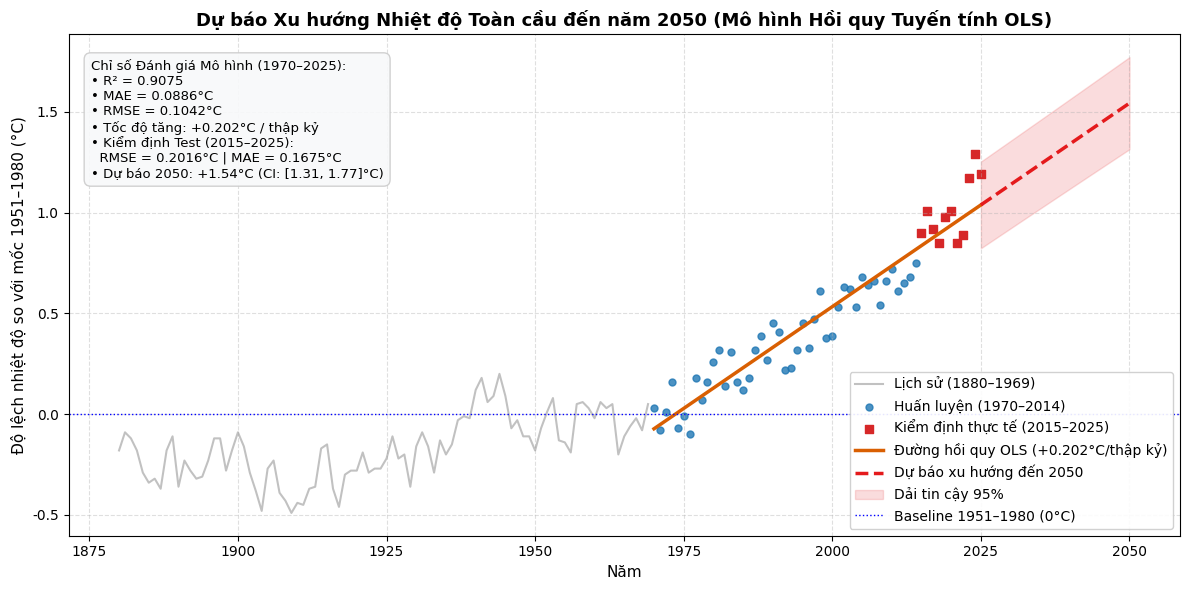

In [8]:
# 1. Chuẩn bị dữ liệu mô hình hồi quy tuyến tính
df_mod = df_nasa_final[df_nasa_final['year'] >= 1970].copy()
train = df_mod[df_mod['year'] <= 2014]
test = df_mod[df_mod['year'] >= 2015]

# 2. Huấn luyện mô hình trên tập Train (1970–2014)
lr_train = LinearRegression()
lr_train.fit(train[['year']], train['temperature_anomaly'])
test_pred = lr_train.predict(test[['year']])
test_mae = mean_absolute_error(test['temperature_anomaly'], test_pred)
test_rmse = np.sqrt(mean_squared_error(test['temperature_anomaly'], test_pred))

# 3. Huấn luyện mô hình trên toàn chuỗi hiện đại (1970–2025)
lr_full = LinearRegression()
lr_full.fit(df_mod[['year']], df_mod['temperature_anomaly'])
full_pred = lr_full.predict(df_mod[['year']])
full_r2 = r2_score(df_mod['temperature_anomaly'], full_pred)
full_mae = mean_absolute_error(df_mod['temperature_anomaly'], full_pred)
full_rmse = np.sqrt(mean_squared_error(df_mod['temperature_anomaly'], full_pred))
slope_decade = lr_full.coef_[0] * 10

# 4. Ngoại suy dự báo xu hướng đến năm 2050
future_years = np.arange(2025, 2051)
future_df = pd.DataFrame({'year': future_years})
future_pred = lr_full.predict(future_df)

# Tính dải tin cậy 95% (Prediction Interval)
residuals = df_mod['temperature_anomaly'] - full_pred
dof = len(df_mod) - 2
s_err = np.sqrt(np.sum(residuals**2) / dof)
x_mean = df_mod['year'].mean()
ss_x = np.sum((df_mod['year'] - x_mean)**2)
pi = 1.96 * s_err * np.sqrt(1 + 1 / len(df_mod) + (future_years - x_mean)**2 / ss_x)
upper_pi = future_pred + pi
lower_pi = future_pred - pi

# --- VẼ BIỂU ĐỒ TĨNH MATPLOTLIB ---
plt.figure(figsize=(12, 6))
pre = df_nasa_final[df_nasa_final['year'] < 1970]
plt.plot(pre['year'], pre['temperature_anomaly'], color='#999999', alpha=0.6, label='Lịch sử (1880–1969)')
plt.scatter(train['year'], train['temperature_anomaly'], color='#1f77b4', s=25, alpha=0.8, label='Huấn luyện (1970–2014)')
plt.scatter(test['year'], test['temperature_anomaly'], color='#d62728', s=35, marker='s', label='Kiểm định thực tế (2015–2025)')
plt.plot(df_mod['year'], full_pred, color='#d95f02', linewidth=2.5, label=f'Đường hồi quy OLS (+{slope_decade:.3f}°C/thập kỷ)')
plt.plot(future_years, future_pred, color='#e41a1c', linestyle='--', linewidth=2.5, label='Dự báo xu hướng đến 2050')
plt.fill_between(future_years, lower_pi, upper_pi, color='#e41a1c', alpha=0.15, label='Dải tin cậy 95%')
plt.axhline(0, color='blue', linestyle=':', linewidth=1, label='Baseline 1951–1980 (0°C)')

plt.title('Dự báo Xu hướng Nhiệt độ Toàn cầu đến năm 2050 (Mô hình Hồi quy Tuyến tính OLS)', fontsize=13, fontweight='bold')
plt.xlabel('Năm', fontsize=11)
plt.ylabel('Độ lệch nhiệt độ so với mốc 1951–1980 (°C)', fontsize=11)

metrics_text = (
    f'Chỉ số Đánh giá Mô hình (1970–2025):\n'
    f'• R² = {full_r2:.4f}\n'
    f'• MAE = {full_mae:.4f}°C\n'
    f'• RMSE = {full_rmse:.4f}°C\n'
    f'• Tốc độ tăng: +{slope_decade:.3f}°C / thập kỷ\n'
    f'• Kiểm định Test (2015–2025):\n'
    f'  RMSE = {test_rmse:.4f}°C | MAE = {test_mae:.4f}°C\n'
    f'• Dự báo 2050: +{future_pred[-1]:.2f}°C (CI: [{lower_pi[-1]:.2f}, {upper_pi[-1]:.2f}]°C)'
)
plt.gca().text(
    0.02, 0.95, metrics_text, transform=plt.gca().transAxes, fontsize=9.5,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#f8f9fa', edgecolor='#cccccc', alpha=0.9)
)
plt.legend(loc='lower right', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../../eda/duc/bieu_do_tinh/06_du_bao_hoi_quy_tuyen_tinh.png', dpi=300)
plt.show()

# --- VẼ BIỂU ĐỒ TƯƠNG TÁC PLOTLY ---
fig_reg = go.Figure()
fig_reg.add_trace(go.Scatter(
    x=pre['year'], y=pre['temperature_anomaly'],
    mode='lines+markers', name='Lịch sử (1880–1969)',
    line=dict(color='#999999', width=1.5), marker=dict(size=4, color='#999999'),
    hovertemplate='Năm %{x}: %{y:.3f}°C<extra></extra>'
))
fig_reg.add_trace(go.Scatter(
    x=train['year'], y=train['temperature_anomaly'],
    mode='markers', name='Huấn luyện (1970–2014)',
    marker=dict(size=6, color='#1f77b4'),
    hovertemplate='Năm %{x}: %{y:.3f}°C (Train)<extra></extra>'
))
fig_reg.add_trace(go.Scatter(
    x=test['year'], y=test['temperature_anomaly'],
    mode='markers', name='Kiểm định thực tế (2015–2025)',
    marker=dict(size=8, symbol='square', color='#d62728'),
    hovertemplate='Năm %{x}: %{y:.3f}°C (Test)<extra></extra>'
))
fig_reg.add_trace(go.Scatter(
    x=df_mod['year'], y=full_pred,
    mode='lines', name=f'Hồi quy OLS (+{slope_decade:.3f}°C/thập kỷ)',
    line=dict(color='#d95f02', width=2.5), 
    hovertemplate='Hồi quy %{x}: %{y:.3f}°C<extra></extra>'
))
fig_reg.add_trace(go.Scatter(
    x=future_years, y=future_pred,
    mode='lines', name='Dự báo đến 2050',
    line=dict(color='#e41a1c', width=2.5, dash='dash'),
    hovertemplate='Dự báo %{x}: %{y:.3f}°C<extra></extra>'
))
fig_reg.add_trace(go.Scatter(
    x=np.concatenate([future_years, future_years[::-1]]),
    y=np.concatenate([upper_pi, lower_pi[::-1]]),
    fill='toself', fillcolor='rgba(228, 26, 28, 0.15)',
    line=dict(color='rgba(255,255,255,0)'),
    hoverinfo='skip', showlegend=True, name='Dải tin cậy 95%'
))
fig_reg.add_hline(y=0, line_dash='dot', line_color='blue', annotation_text='Baseline 1951–1980 (0°C)')

fig_reg.update_layout(
    title='<b>Dự báo Xu hướng Nhiệt độ Toàn cầu đến năm 2050 (Mô hình Hồi quy Tuyến tính OLS)</b>',
    xaxis_title='Năm',
    yaxis_title='Độ lệch nhiệt độ so với mốc 1951–1980 (°C)',
    template='plotly_white',
    hovermode='x unified',
    legend=dict(yanchor='top', y=0.99, xanchor='left', x=0.01, bgcolor='rgba(255,255,255,0.8)'),
    annotations=[dict(
        x=2050, y=future_pred[-1],
        text=f'2050: +{future_pred[-1]:.2f}°C',
        showarrow=True, arrowhead=2, ax=-40, ay=-30,
        bgcolor='#ffebee', bordercolor='#d32f2f'
    )]
)
fig_reg.write_html('../../eda/duc/bieu_do_tuong_tac/06_du_bao_hoi_quy_tuyen_tinh.html', include_plotlyjs='cdn')
fig_reg.show()